In [18]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix
from statsmodels.nonparametric.smoothers_lowess import lowess

Set constants and load data

In [2]:
# set variables
threshold = 0.1
look_back = 2
look_forward_time = 8
refractory_time = 8

In [26]:
# set file path
# Make sure there are three folders: Code, Data, Results to read from and write to
file_path = "C:/Users/jenan/OneDrive - Tufts Medicine/code/EDSValidation_Jennie"
data_path = "C:/Users/jenan/OneDrive - Tufts Medicine/code/EDSValidation_Jennie/Data/Time_Dependent_All/Refractory"
data_save_path = os.path.join(data_path, f'Threshold_{int(threshold * 100)}_Lookforward_{look_forward_time}')

In [ ]:
# load data
with open(f"{file_path}/Data/patient.data.pkl", 'rb') as f:
    data = pickle.load(f)
patient_data = data['patient_data']
print(patient_data.shape)

Prep Data

In [ ]:
# create a list of dfs, 1 df per LCSN
patient_df_list = [group.reset_index(drop=True) for _, group in patient_data.groupby('LCSN')]
# remove dfs where patient doesn't have x hours of data
patient_df_list_filtered = [df for df in patient_df_list if len(df) >= (look_back * 4 + 1)]

Refractory Period

In [ ]:
# refractory period, turn off alarms
# when alarm goes off, turn off alarm for the next x (refractory period) hours, alarms/the alarms do not go through
# alarm is if model.score >= threshold

In [ ]:
refractory_period_df_list = []

for df in tqdm(patient_df_list_filtered):
    df['refractory_alarm'] = 0
    i = 0
    # if alarm at time point = 1, skip the next x hours, then continue the process
    while i < len(df):
        if df.at[i, 'model.score'] >= threshold:
            df.at[i, 'refractory_alarm'] = 1
            for j in range(i + 1, min(i + (refractory_time * 4 + 1), len(df))):
                df.at[j, 'refractory_alarm'] = 0
            i += (refractory_time * 4 + 1)
        else:
            df.at[i, 'refractory_alarm'] = 0
            i += 1
    refractory_period_df_list.append(df)

100%|██████████| 26520/26520 [01:06<00:00, 398.29it/s]


Get Look back max and look forward outcome

In [ ]:
# at each time point, look at time frame x hours back, look forward y hours to see outcome
# track if alarm went off in past x hours, and outcome in next y hours
# start from time point x * 4 (since we need to look back x hours)
# loop through list of dfs
new_refractory_period_df_list = []
for patient_df in tqdm(refractory_period_df_list):
    alarm_pred_list = []
    outcome_list = []

    for time_point in patient_df['time.point']:
        if (time_point >= (look_back * 4)) and (patient_df['time.sep3.outcome'].iloc[time_point] != 1):
            alarm_pred = (patient_df.iloc[(time_point - (look_back * 4)):time_point]['refractory_alarm'] == 1).any()
            outcome = (patient_df.iloc[time_point:time_point + (look_forward_time * 4)]['time.sep3.outcome'] == 1).any()
            alarm_pred_list.append(alarm_pred)
            outcome_list.append(outcome)
        else:
            alarm_pred_list.append(-1)
            outcome_list.append(-1)
    
    new_df = patient_df.copy()
    new_df['look_back_alarm'] = alarm_pred_list
    new_df['look_forward_outcome'] = outcome_list
    new_refractory_period_df_list.append(new_df)

100%|██████████| 26520/26520 [07:49<00:00, 56.52it/s] 


In [ ]:
# recombine dfs, save
combined_df = pd.concat(new_refractory_period_df_list, ignore_index=True)
# remove all rows where look_back_max or look_forward_outcome are -1
combined_df_filtered = combined_df[~((combined_df['look_back_alarm'] == -1) & (combined_df['look_forward_outcome'] == -1))]

In [ ]:
# save
combined_df_filtered.to_csv(os.path.join(data_save_path, 'Time_Dependent_Data.csv'), index = False)

GO FROM HERE FOR PLOT

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix
from statsmodels.nonparametric.smoothers_lowess import lowess

In [2]:
# set variables
threshold = 0.25
look_back = 2
look_forward_time = 8

In [3]:
# set file path
# Make sure there are three folders: Code, Data, Results to read from and write to
file_path = "C:/Users/jenan/OneDrive - Tufts Medicine/code/EDSValidation_Jennie"
data_path = "C:/Users/jenan/OneDrive - Tufts Medicine/code/EDSValidation_Jennie/Data/Time_Dependent_All/Refractory"
data_save_path = os.path.join(data_path, f'Threshold_{int(threshold * 100)}_Lookforward_{look_forward_time}')

In [4]:
combined_df_filtered = pd.read_csv(os.path.join(data_save_path, 'Time_Dependent_Data.csv'))

C:\Users\jenan\AppData\Local\Temp\ipykernel_25508\408789044.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_df_filtered = pd.read_csv(os.path.join(data_save_path, 'Time_Dependent_Data.csv'))


In [5]:
# replace true in look_forward_outcome and look_back_alarm with 1 and false with 0
combined_df_filtered['look_forward_outcome'] = combined_df_filtered['look_forward_outcome'].astype(int)
combined_df_filtered['look_back_alarm'] = combined_df_filtered['look_back_alarm'].astype(int)

In [6]:
# create list of dfs grouped by time point
time_point_df_list = [group for _, group in combined_df_filtered.groupby('time.point')]

In [7]:
# get metrics at each time point
# prediction = alarm went off (max score in past x hours is >= threshold)
# outcome = if there was sepsis in the next 8 hours or not

# loop through each time point
time_point = []
incidence = []
tp = []
fp = []
tn = []
fn = []
auc = []
sensitivity = []
specificity = []
ppv = []
npv = []
at_risk = []

for df in tqdm(time_point_df_list):
    predictions = df['look_back_alarm']
    outcomes = df['look_forward_outcome']

    time_point.append(df['time.point'].iloc[0])

    incidence.append(np.mean(outcomes) * 100)
    tp_val = np.sum((outcomes == 1) & (predictions == 1))  
    fp_val = np.sum((outcomes == 0) & (predictions == 1))  
    tn_val = np.sum((outcomes == 0) & (predictions == 0))  
    fn_val = np.sum((outcomes == 1) & (predictions == 0))  
    tp.append(tp_val)
    fp.append(fp_val)
    tn.append(tn_val)
    fn.append(fn_val)

    auc_value = roc_auc_score(outcomes, predictions)
    auc.append(auc_value)

    sensitivity_value = tp_val / (tp_val + fn_val) if tp_val + fn_val > 0 else 0
    sensitivity.append(sensitivity_value)
    specificity_value = tn_val / (tn_val + fp_val) if tn_val + fp_val > 0 else 0
    specificity.append(specificity_value)

    ppv_value = tp_val / (tp_val + fp_val) if tp_val + fp_val > 0 else 0
    ppv.append(ppv_value)
    npv_value = tn_val / (tn_val + fn_val) if tn_val + fn_val > 0 else 0
    npv.append(npv_value)

    at_risk.append(len(df))

  3%|▎         | 304/10138 [00:00<00:15, 654.89it/s]c:\Users\jenan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\jenan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\jenan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\jenan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
  7%|▋         | 683/10138 [00:01<00:12,

In [8]:
# get df of results
results_df = pd.DataFrame({
    'Time Point': time_point,
    'Incidence': incidence,
    'TP': tp,
    'FP': fp,
    'TN': tn,
    'FN': fn,
    'AUC': auc,
    'Sensitivity': sensitivity,
    'Specificity': specificity,
    'PPV': ppv,
    'NPV': npv,
    'At Risk': at_risk
})

In [9]:
# reorder results df
results_df.sort_values(by='Time Point', ascending=True, inplace=False)
results_df

,Time Point,Incidence,TP,FP,TN,FN,AUC,Sensitivity,Specificity,PPV,NPV,At Risk
0,8,1.290663,200,3401,22755,142,0.727384,0.584795,0.869972,0.055540,0.993798,26498
1,9,1.237604,63,764,24134,249,0.585619,0.201923,0.969315,0.076179,0.989788,25210
2,10,1.219309,43,460,23196,249,0.563907,0.147260,0.980555,0.085487,0.989379,23948
3,11,1.197130,33,310,22139,239,0.553757,0.121324,0.986191,0.096210,0.989320,22721
4,12,1.165058,23,253,21040,228,0.539876,0.091633,0.988118,0.083333,0.989280,21544
...,...,...,...,...,...,...,...,...,...,...,...,...
10133,10141,0.000000,0,0,1,0,NaN,0.000000,1.000000,0.000000,1.000000,1
10134,10142,0.000000,0,0,1,0,NaN,0.000000,1.000000,0.000000,1.000000,1
10135,10143,0.000000,0,0,1,0,NaN,0.000000,1.000000,0.000000,1.000000,1
10136,10144,0.000000,0,0,1,0,NaN,0.000000,1.000000,0.000000,1.000000,1


In [10]:
# save
results_df.to_csv(os.path.join(data_save_path, 'Time_dependent_metric_results.csv'), index = False)

In [11]:
# subset df for 3.5 days, set legend to be in days
subset_results_df = results_df[results_df['Time Point'] <= 336]
subset_results_df['Time Point Days'] = subset_results_df['Time Point'] / 96

C:\Users\jenan\AppData\Local\Temp\ipykernel_25508\2903172409.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_results_df['Time Point Days'] = subset_results_df['Time Point'] / 96


In [12]:
days = [8, 48, 96, 144, 192, 240, 288, 336]
table_df = subset_results_df[subset_results_df['Time Point'].isin(days)][['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN']]
table_df[['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN']] = table_df[['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN']].round(2)
table_df = table_df.T

In [13]:
subset_results_df

,Time Point,Incidence,TP,FP,TN,FN,AUC,Sensitivity,Specificity,PPV,NPV,At Risk,Time Point Days
0,8,1.290663,200,3401,22755,142,0.727384,0.584795,0.869972,0.055540,0.993798,26498,0.083333
1,9,1.237604,63,764,24134,249,0.585619,0.201923,0.969315,0.076179,0.989788,25210,0.093750
2,10,1.219309,43,460,23196,249,0.563907,0.147260,0.980555,0.085487,0.989379,23948,0.104167
3,11,1.197130,33,310,22139,239,0.553757,0.121324,0.986191,0.096210,0.989320,22721,0.114583
4,12,1.165058,23,253,21040,228,0.539876,0.091633,0.988118,0.083333,0.989280,21544,0.125000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,332,0.157027,1,26,3789,5,0.579926,0.166667,0.993185,0.037037,0.998682,3821,3.458333
325,333,0.157522,0,27,3776,6,0.496450,0.000000,0.992900,0.000000,0.998414,3809,3.468750
326,334,0.131683,0,26,3766,5,0.496572,0.000000,0.993143,0.000000,0.998674,3797,3.479167
327,335,0.131891,0,27,3759,5,0.496434,0.000000,0.992868,0.000000,0.998672,3791,3.489583


In [14]:
subset_results_df['AUC'] = subset_results_df['AUC'].fillna(method='ffill')

C:\Users\jenan\AppData\Local\Temp\ipykernel_25508\724104491.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  subset_results_df['AUC'] = subset_results_df['AUC'].fillna(method='ffill')
C:\Users\jenan\AppData\Local\Temp\ipykernel_25508\724104491.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_results_df['AUC'] = subset_results_df['AUC'].fillna(method='ffill')


In [15]:
def check_nans_in_columns(df, columns):
    for col in columns:
        n_missing = df[col].isna().sum()
        print(f"Column '{col}' has {n_missing} missing values (NaNs)")
cols_to_check = ['Time Point Days', 'Incidence', 'AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV']
check_nans_in_columns(subset_results_df, cols_to_check)

Column 'Time Point Days' has 0 missing values (NaNs)
Column 'Incidence' has 0 missing values (NaNs)
Column 'AUC' has 0 missing values (NaNs)
Column 'Sensitivity' has 0 missing values (NaNs)
Column 'Specificity' has 0 missing values (NaNs)
Column 'PPV' has 0 missing values (NaNs)
Column 'NPV' has 0 missing values (NaNs)


In [16]:
subset_results_df_to_smooth = subset_results_df.copy()

In [17]:
# LOWESS SMOOTHING FOR EACH COL BASED ON TIME POINT DAYS X
def apply_lowess_multiple(df, x_col, y_cols, frac):
    for col in y_cols:
        smoothed = lowess(df[col], df[x_col], frac)
        df[col] = smoothed[:, 1]
    return df
subset_results_df_smoothed = apply_lowess_multiple(subset_results_df_to_smooth, 'Time Point Days', ['Incidence', 'AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV'], 0.15)

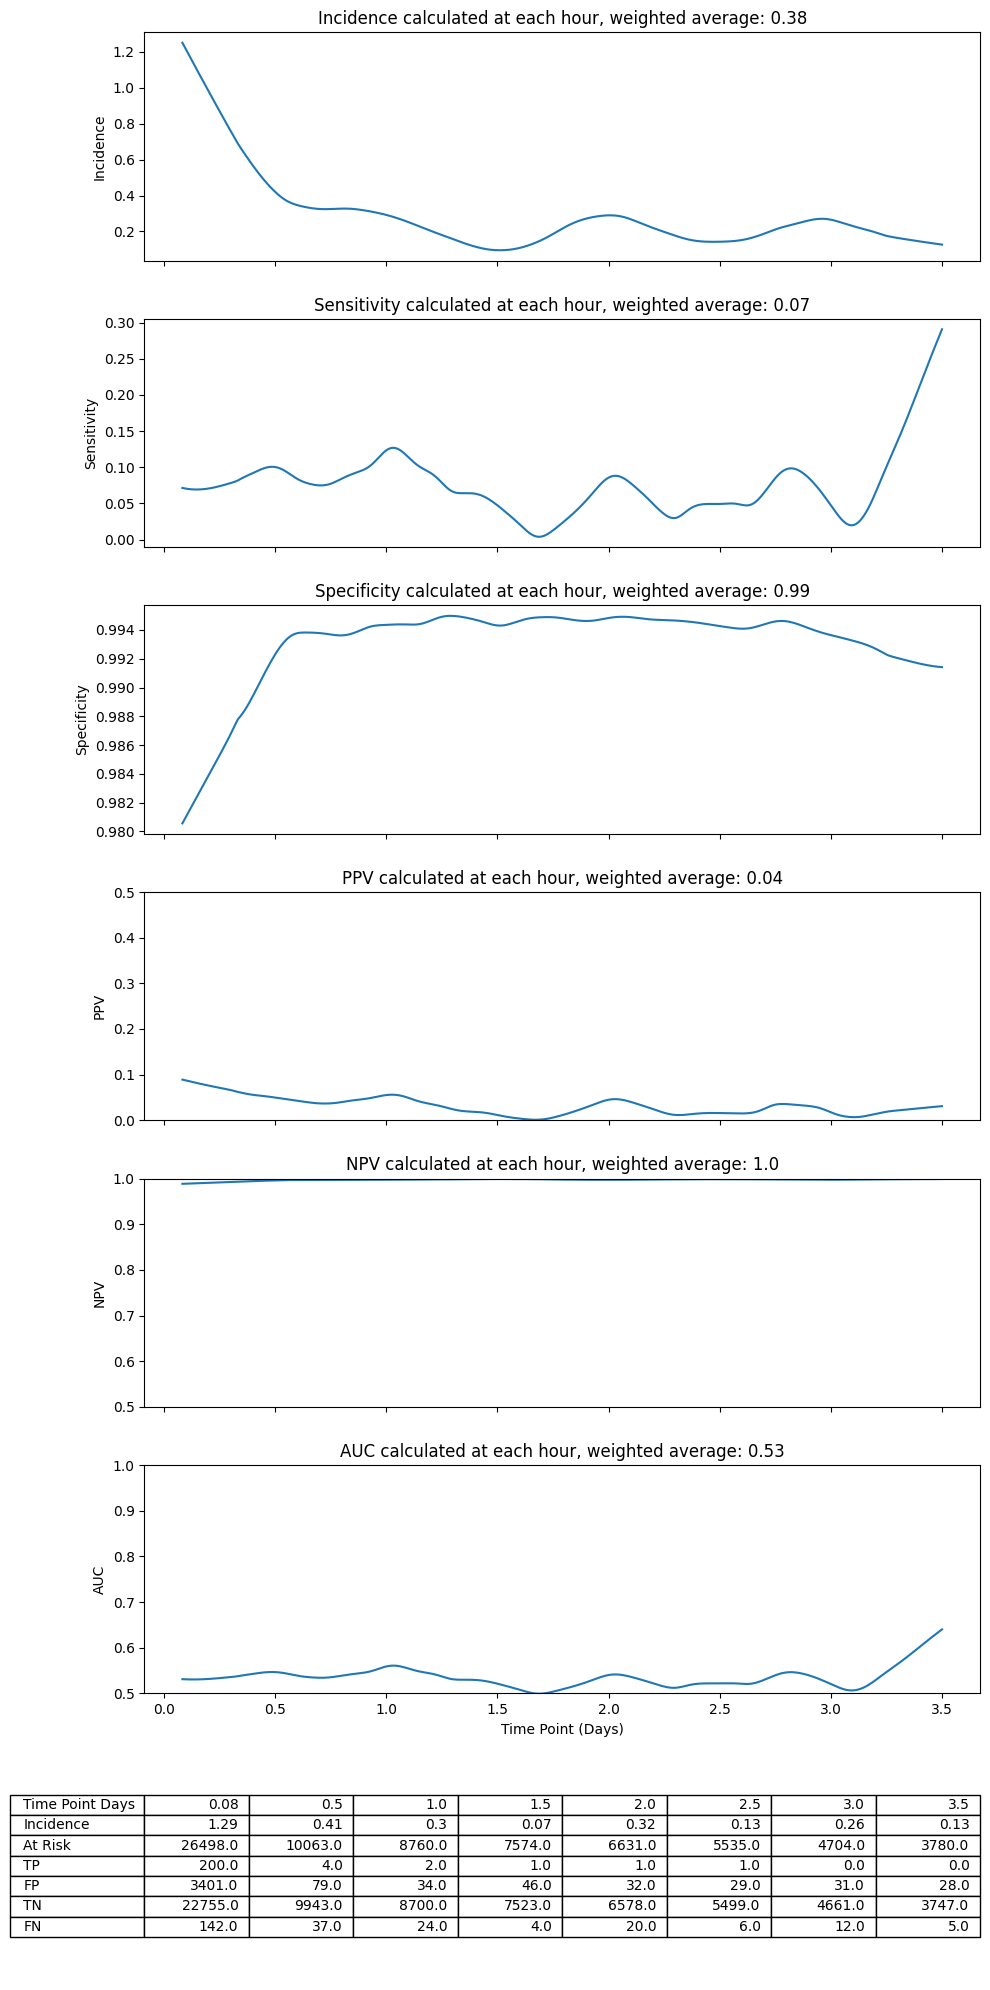

In [18]:
# plot (3.5 days, x axis in days), old version all 1 col
fig, axs = plt.subplots(7, 1, sharex=True, figsize=(10, 20))

axs[0].plot(subset_results_df_smoothed['Time Point Days'], subset_results_df_smoothed['Incidence'], label='Prevalence')
axs[0].set_ylabel('Incidence')
weighted_avg = (subset_results_df_smoothed['Incidence'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
axs[0].set_title('Incidence calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[1].plot(subset_results_df_smoothed['Time Point Days'], subset_results_df_smoothed['Sensitivity'], label='Sensitivity')
axs[1].set_ylabel('Sensitivity')
weighted_avg = (subset_results_df_smoothed['Sensitivity'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
axs[1].set_title('Sensitivity calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[2].plot(subset_results_df_smoothed['Time Point Days'], subset_results_df_smoothed['Specificity'], label='Specificity')
axs[2].set_ylabel('Specificity')
weighted_avg = (subset_results_df_smoothed['Specificity'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
axs[2].set_title('Specificity calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[3].plot(subset_results_df_smoothed['Time Point Days'], subset_results_df_smoothed['PPV'], label='PPV')
axs[3].set_ylabel('PPV')
axs[3].set_ylim(0.0, 0.5)
weighted_avg = (subset_results_df_smoothed['PPV'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
axs[3].set_title('PPV calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[4].plot(subset_results_df_smoothed['Time Point Days'], subset_results_df_smoothed['NPV'], label='NPV')
axs[4].set_ylabel('NPV')
axs[4].set_ylim(0.5, 1.0)
weighted_avg = (subset_results_df_smoothed['NPV'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
axs[4].set_title('NPV calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[5].plot(subset_results_df_smoothed['Time Point Days'], subset_results_df_smoothed['AUC'], label='AUC')
axs[5].set_ylabel('AUC')
axs[5].set_ylim(0.5, 1.0)
weighted_avg = (subset_results_df_smoothed['AUC'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
axs[5].set_title('AUC calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[6].axis("off")  
axs[6].table(cellText=table_df.values, rowLabels=['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN'], loc="center")

axs[5].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
axs[5].set_xlabel('Time Point (Days)')

# Adjust spacing between subplots
plt.tight_layout()

# save plot
plt.savefig(os.path.join(data_save_path, 'metric_figure_smoothed.png'))

# Show plot
plt.show()

C:\Users\jenan\AppData\Local\Temp\ipykernel_25508\1442030998.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


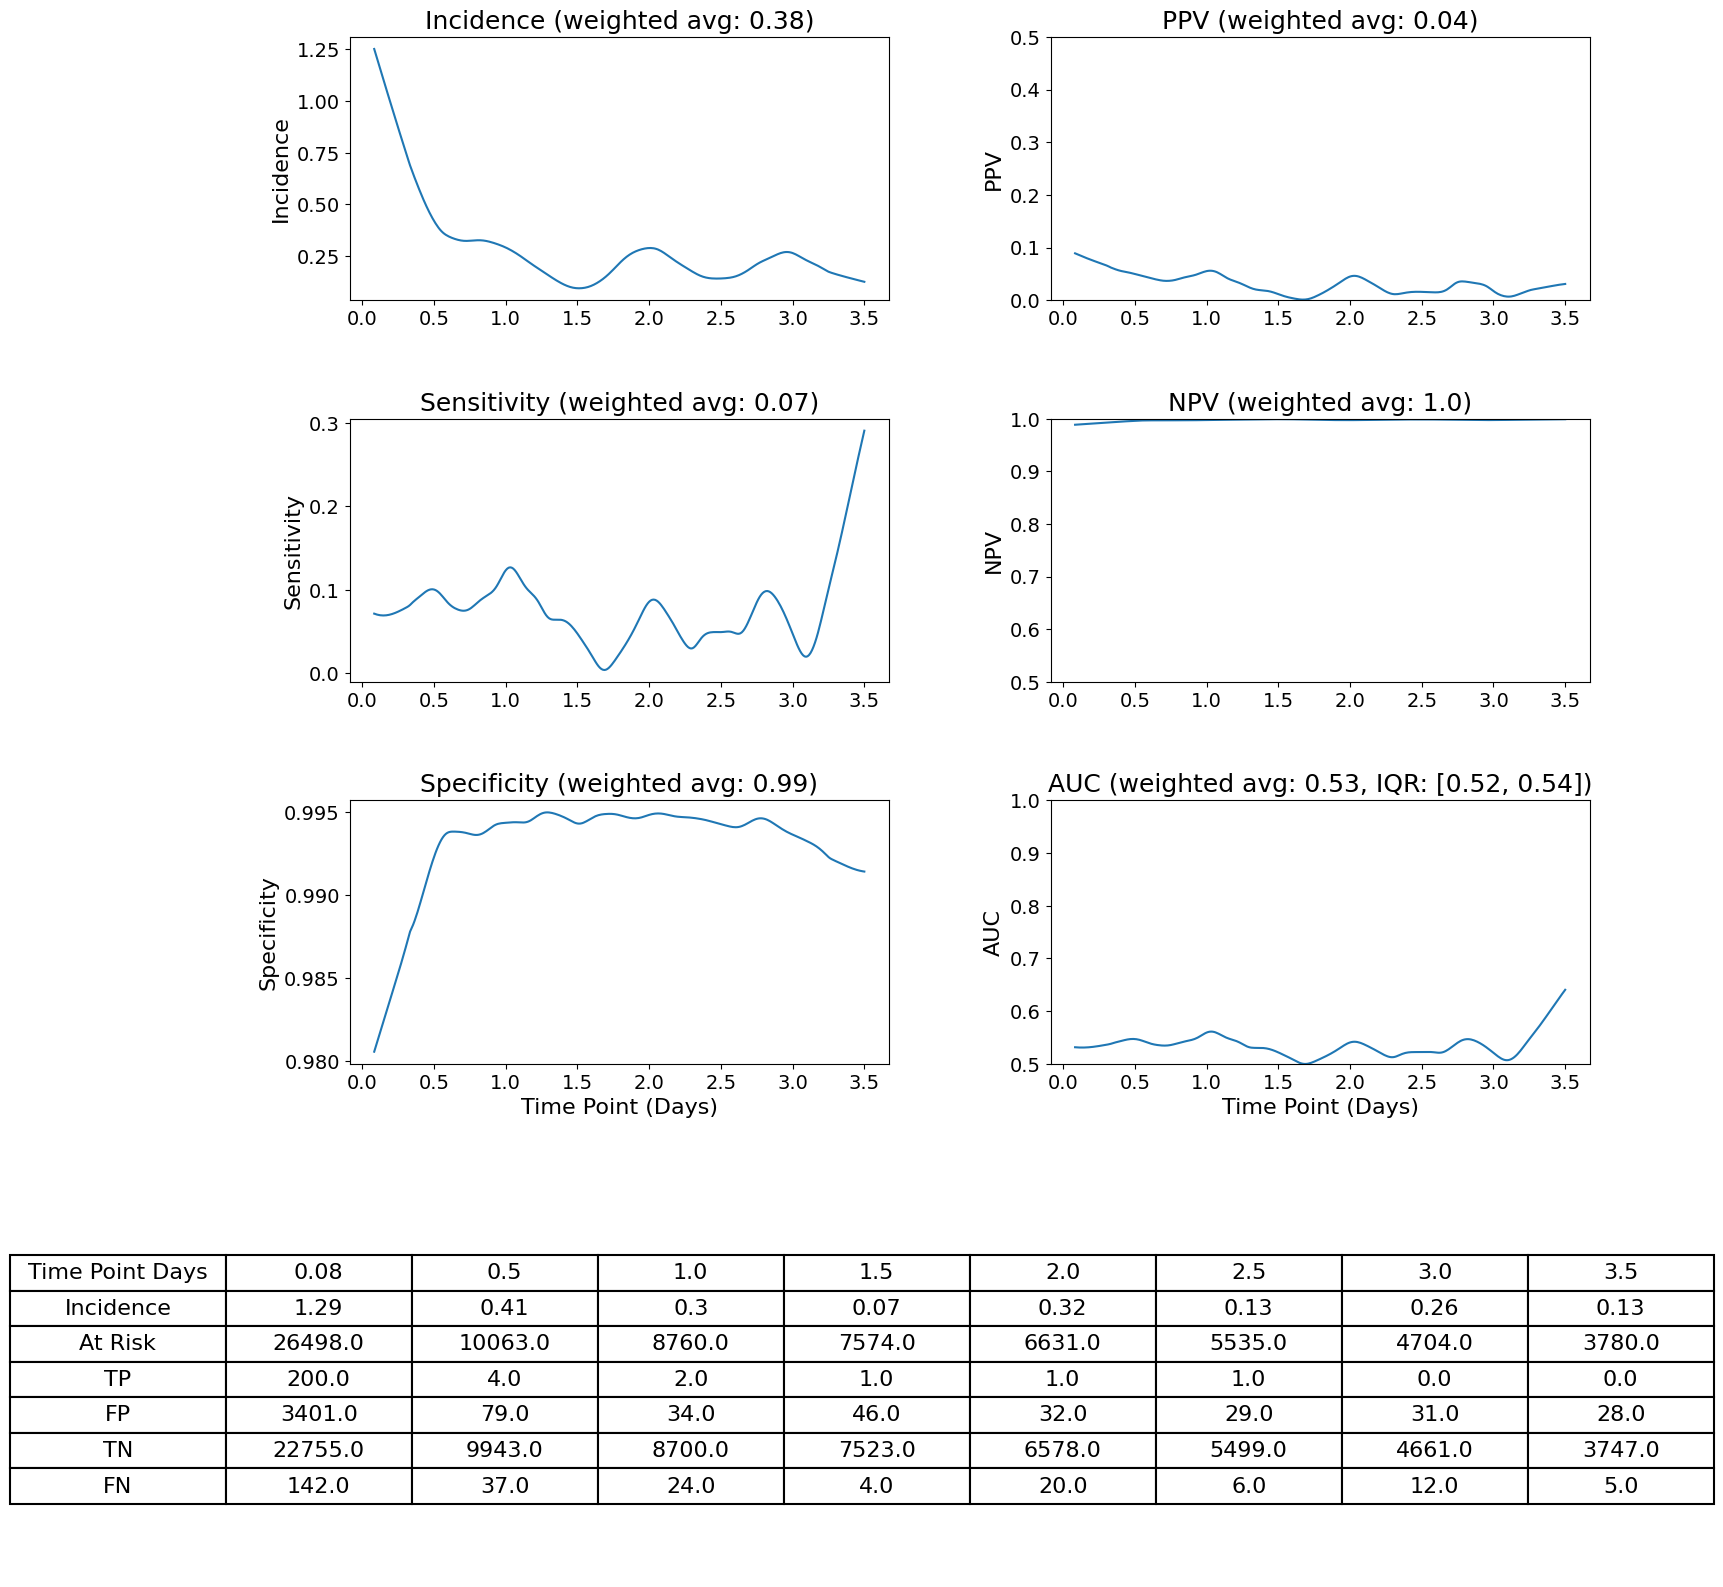

In [19]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Base font sizes
label_fontsize = 16
title_fontsize = 18
tick_fontsize = 14
table_fontsize = 16

# Figure size: wider to match table
fig = plt.figure(figsize=(16, 20))

# GridSpec: 4 rows, 2 columns
# height_ratios: 3 rows of plots, 1 row for table (taller)
# width_ratios: both columns equal width
gs = GridSpec(4, 2, figure=fig, height_ratios=[1, 1, 1, 1.5], width_ratios=[1, 1], hspace=0.4, wspace=0.3)

# ---- Create axes ----
# Left column plots
ax_inc = fig.add_subplot(gs[0, 0])
ax_sens = fig.add_subplot(gs[1, 0], sharex=ax_inc)
ax_spec = fig.add_subplot(gs[2, 0], sharex=ax_inc)

# Right column plots
ax_ppv = fig.add_subplot(gs[0, 1], sharex=ax_inc)
ax_npv = fig.add_subplot(gs[1, 1], sharex=ax_inc)
ax_auc = fig.add_subplot(gs[2, 1], sharex=ax_inc)

# Bottom table spanning both columns
ax_table = fig.add_subplot(gs[3, :])

# ---- Left column ----
ax_inc.plot(subset_results_df_smoothed['Time Point Days'],
            subset_results_df_smoothed['Incidence'])
ax_inc.set_ylabel('Incidence', fontsize=label_fontsize)
weighted_avg = (subset_results_df_smoothed['Incidence'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_inc.set_title(f'Incidence (weighted avg: {round(weighted_avg, 2)})', fontsize=title_fontsize)
ax_inc.tick_params(axis='both', labelsize=tick_fontsize)

ax_sens.plot(subset_results_df_smoothed['Time Point Days'],
             subset_results_df_smoothed['Sensitivity'])
ax_sens.set_ylabel('Sensitivity', fontsize=label_fontsize)
weighted_avg = (subset_results_df_smoothed['Sensitivity'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_sens.set_title(f'Sensitivity (weighted avg: {round(weighted_avg, 2)})', fontsize=title_fontsize)
ax_sens.tick_params(axis='both', labelsize=tick_fontsize)

ax_spec.plot(subset_results_df_smoothed['Time Point Days'],
             subset_results_df_smoothed['Specificity'])
ax_spec.set_ylabel('Specificity', fontsize=label_fontsize)
weighted_avg = (subset_results_df_smoothed['Specificity'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_spec.set_title(f'Specificity (weighted avg: {round(weighted_avg, 2)})', fontsize=title_fontsize)
ax_spec.tick_params(axis='both', labelsize=tick_fontsize)

# ---- Right column ----
ax_ppv.plot(subset_results_df_smoothed['Time Point Days'],
            subset_results_df_smoothed['PPV'])
ax_ppv.set_ylabel('PPV', fontsize=label_fontsize)
ax_ppv.set_ylim(0.0, 0.5)
weighted_avg = (subset_results_df_smoothed['PPV'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_ppv.set_title(f'PPV (weighted avg: {round(weighted_avg, 2)})', fontsize=title_fontsize)
ax_ppv.tick_params(axis='both', labelsize=tick_fontsize)

ax_npv.plot(subset_results_df_smoothed['Time Point Days'],
            subset_results_df_smoothed['NPV'])
ax_npv.set_ylabel('NPV', fontsize=label_fontsize)
ax_npv.set_ylim(0.5, 1.0)
weighted_avg = (subset_results_df_smoothed['NPV'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_npv.set_title(f'NPV (weighted avg: {round(weighted_avg, 2)})', fontsize=title_fontsize)
ax_npv.tick_params(axis='both', labelsize=tick_fontsize)

ax_auc.plot(subset_results_df_smoothed['Time Point Days'],
            subset_results_df_smoothed['AUC'])
ax_auc.set_ylabel('AUC', fontsize=label_fontsize)
ax_auc.set_ylim(0.5, 1.0)
q1 = subset_results_df_smoothed['AUC'].quantile(0.25)
q3 = subset_results_df_smoothed['AUC'].quantile(0.75)
weighted_avg = (subset_results_df_smoothed['AUC'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_auc.set_title(f'AUC (weighted avg: {round(weighted_avg, 2)}, IQR: [{round(q1, 2)}, {round(q3, 2)}])', fontsize=title_fontsize)
ax_auc.tick_params(axis='both', labelsize=tick_fontsize)

# Shared x-label for bottom plots
ax_spec.set_xlabel('Time Point (Days)', fontsize=label_fontsize)
ax_auc.set_xlabel('Time Point (Days)', fontsize=label_fontsize)

# ---- Bottom table ----
ax_table.axis("off")
table = ax_table.table(
    cellText=table_df.values,
    rowLabels=['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN'],
    loc="center",
    cellLoc='center',
    rowLoc='center',
    colWidths=[0.15] * table_df.shape[1]
)

# Table font and row height
table.auto_set_font_size(False)
table.set_fontsize(table_fontsize)
for key, cell in table.get_celld().items():
    cell.set_height(0.09)  # increase row height
    cell.set_linewidth(1.5)  # thicker grid lines

# Adjust layout
plt.tight_layout()
plt.savefig(os.path.join(data_save_path, 'metric_figure_smoothed.png'), bbox_inches="tight")
plt.show()

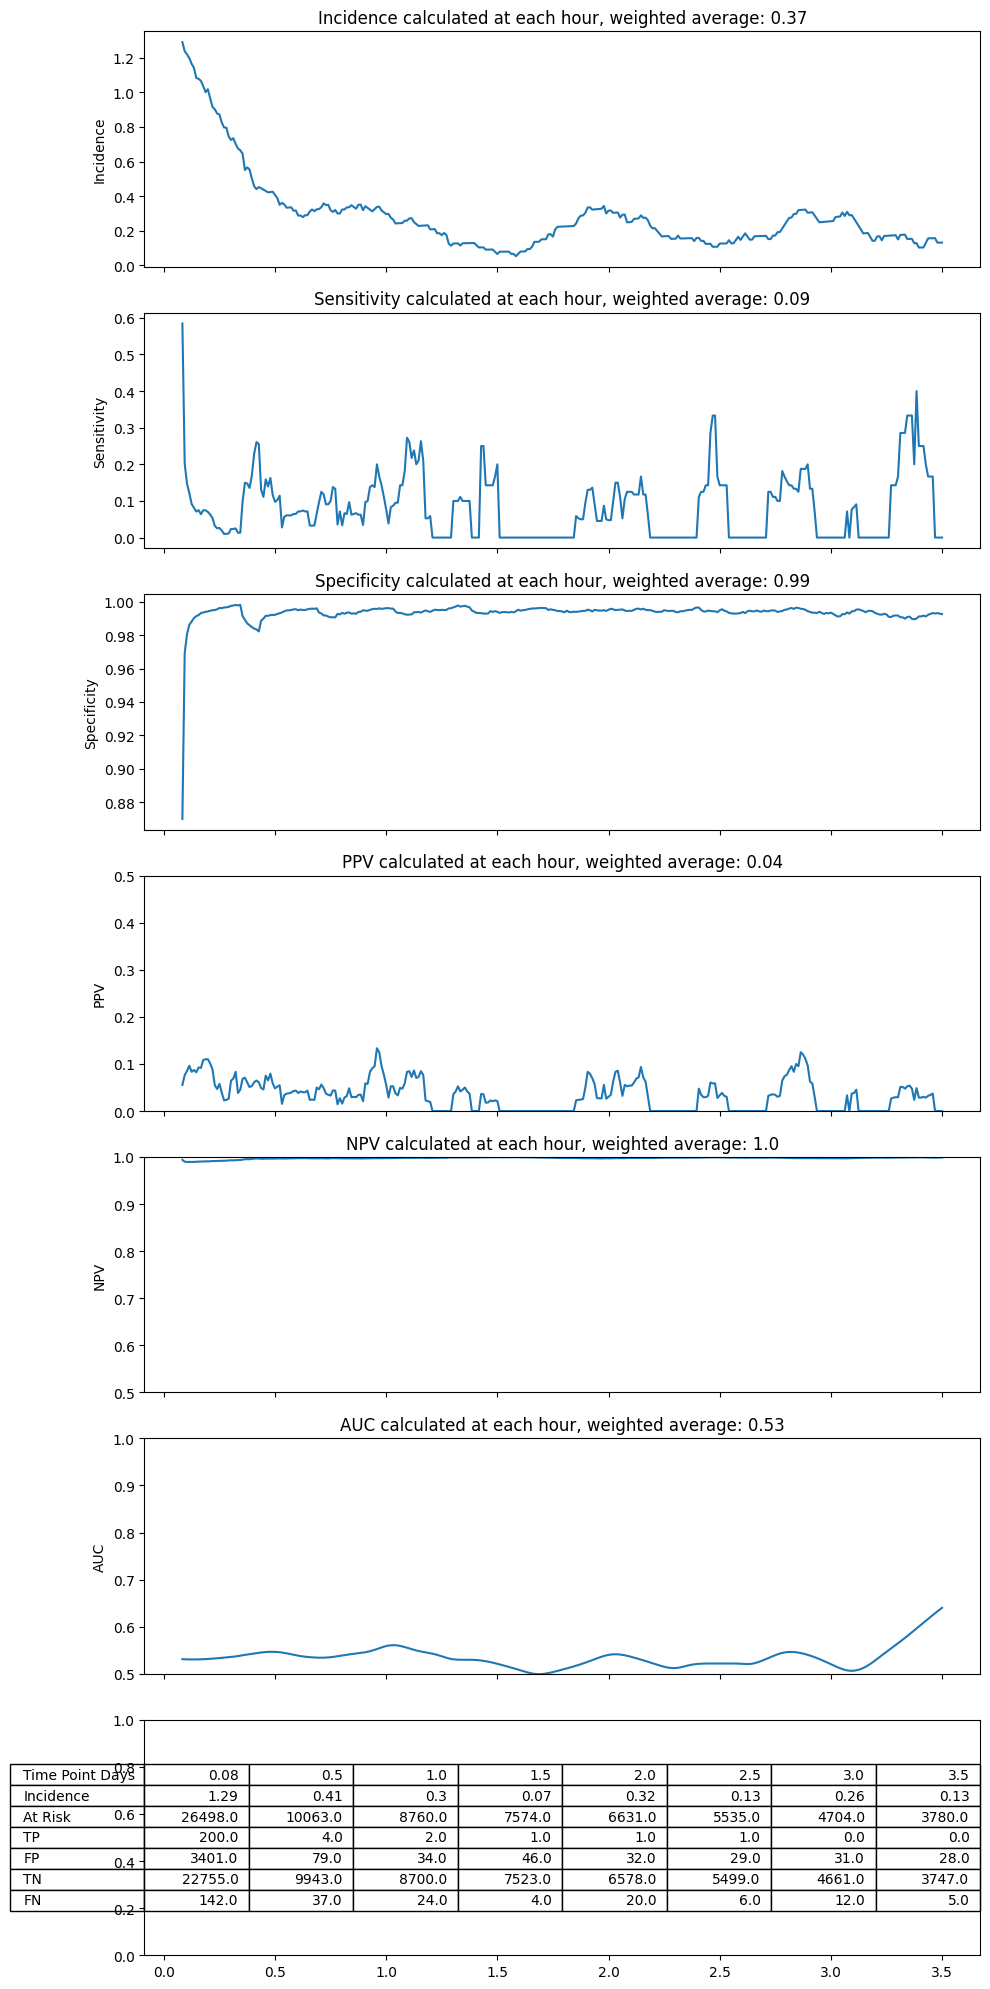

In [20]:
# plot (4 days, x axis in days)
fig, axs = plt.subplots(7, 1, sharex=True, figsize=(10, 20))

axs[0].plot(subset_results_df['Time Point Days'], subset_results_df['Incidence'], label='Prevalence')
axs[0].set_ylabel('Incidence')
weighted_avg = (subset_results_df['Incidence'] * subset_results_df['At Risk']).sum() / subset_results_df['At Risk'].sum()
axs[0].set_title('Incidence calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[1].plot(subset_results_df['Time Point Days'], subset_results_df['Sensitivity'], label='Sensitivity')
axs[1].set_ylabel('Sensitivity')
weighted_avg = (subset_results_df['Sensitivity'] * subset_results_df['At Risk']).sum() / subset_results_df['At Risk'].sum()
axs[1].set_title('Sensitivity calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[2].plot(subset_results_df['Time Point Days'], subset_results_df['Specificity'], label='Specificity')
axs[2].set_ylabel('Specificity')
weighted_avg = (subset_results_df['Specificity'] * subset_results_df['At Risk']).sum() / subset_results_df['At Risk'].sum()
axs[2].set_title('Specificity calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[3].plot(subset_results_df['Time Point Days'], subset_results_df['PPV'], label='PPV')
axs[3].set_ylabel('PPV')
axs[3].set_ylim(0.0, 0.5)
weighted_avg = (subset_results_df['PPV'] * subset_results_df['At Risk']).sum() / subset_results_df['At Risk'].sum()
axs[3].set_title('PPV calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[4].plot(subset_results_df['Time Point Days'], subset_results_df['NPV'], label='NPV')
axs[4].set_ylabel('NPV')
axs[4].set_ylim(0.5, 1.0)
weighted_avg = (subset_results_df['NPV'] * subset_results_df['At Risk']).sum() / subset_results_df['At Risk'].sum()
axs[4].set_title('NPV calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

axs[5].plot(subset_results_df_smoothed['Time Point Days'], subset_results_df_smoothed['AUC'], label='AUC')
axs[5].set_ylabel('AUC')
axs[5].set_ylim(0.5, 1.0)
weighted_avg = (subset_results_df_smoothed['AUC'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
axs[5].set_title('AUC calculated at each hour, weighted average: ' + str(round(weighted_avg, 2)))

#axs[6].axis("off")  
axs[6].table(cellText=table_df.values, rowLabels=['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN'], loc="center")

# Adjust spacing between subplots
plt.tight_layout()

# save plot
plt.savefig(os.path.join(data_save_path, 'metric_figure.png'))

# Show plot
plt.show()

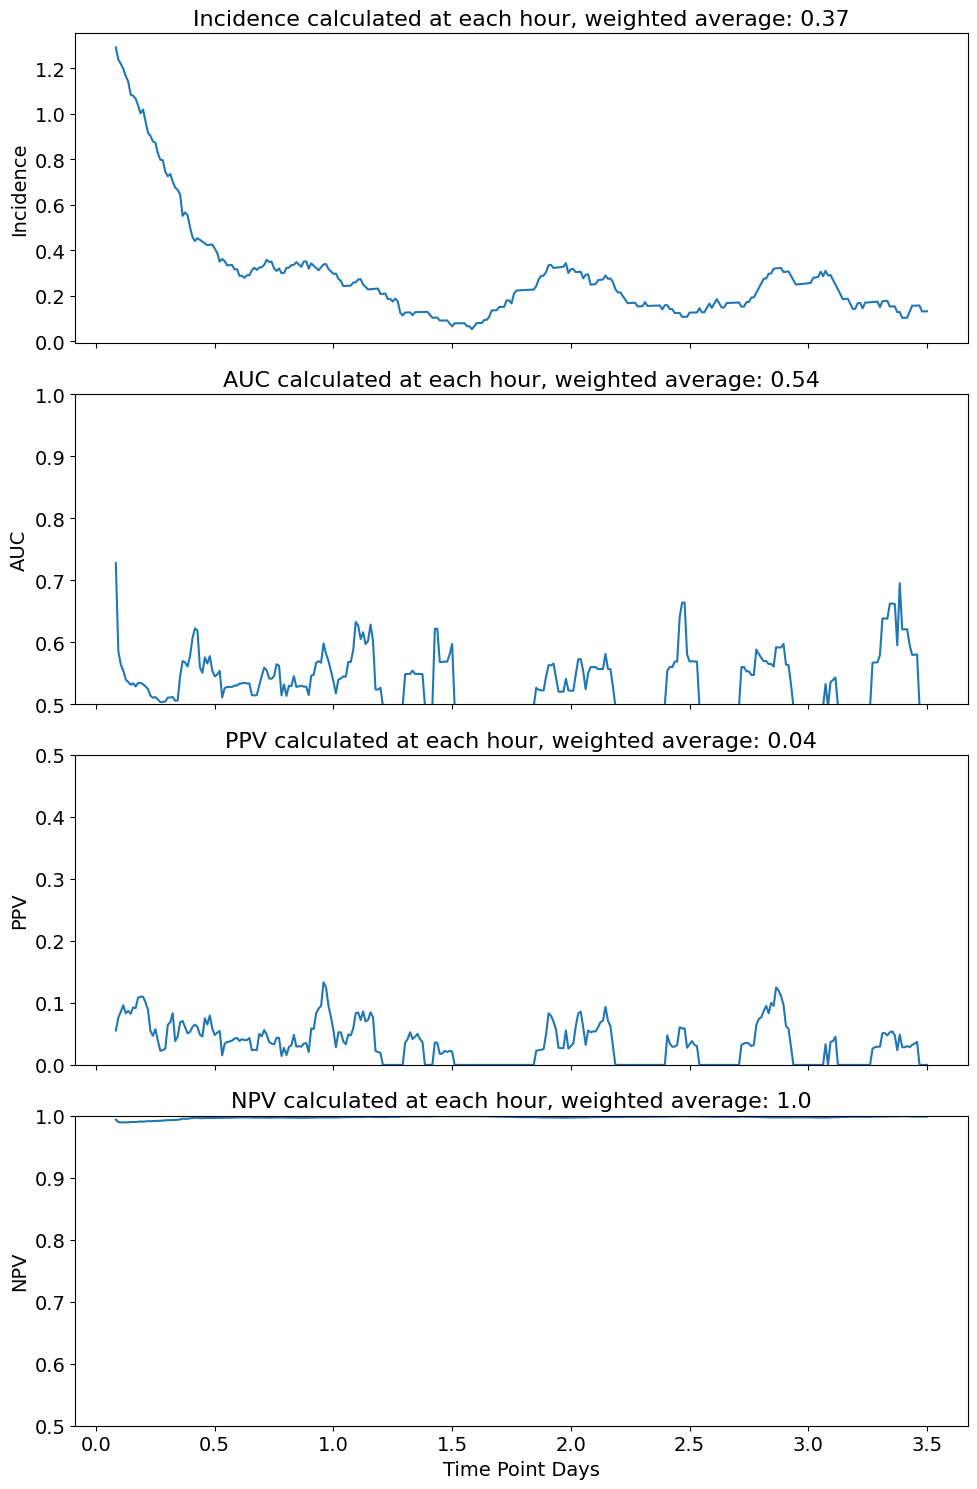

In [21]:
# plot (4 days, x axis in days)
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 15))

label_fontsize = 14
title_fontsize = 16
tick_fontsize = 14

# INCIDENCE
axs[0].plot(subset_results_df['Time Point Days'], subset_results_df['Incidence'], label='Prevalence')
axs[0].set_ylabel('Incidence', fontsize=label_fontsize)
axs[0].set_title('Incidence calculated at each hour, weighted average: ' + str(round(
    (subset_results_df['Incidence'] * subset_results_df['At Risk']).sum() / subset_results_df['At Risk'].sum(), 2)),
    fontsize=title_fontsize)
axs[0].tick_params(axis='both', labelsize=tick_fontsize)

# AUC
axs[1].plot(subset_results_df['Time Point Days'], subset_results_df['AUC'], label='AUC')
axs[1].set_ylabel('AUC', fontsize=label_fontsize)
axs[1].set_ylim(0.5, 1.0)
axs[1].set_title('AUC calculated at each hour, weighted average: ' + str(round(
    (subset_results_df['AUC'] * subset_results_df['At Risk']).sum() / subset_results_df['At Risk'].sum(), 2)),
    fontsize=title_fontsize)
axs[1].tick_params(axis='both', labelsize=tick_fontsize)

# PPV
axs[2].plot(subset_results_df['Time Point Days'], subset_results_df['PPV'], label='PPV')
axs[2].set_ylabel('PPV', fontsize=label_fontsize)
axs[2].set_ylim(0.0, 0.5)
axs[2].set_title('PPV calculated at each hour, weighted average: ' + str(round(
    (subset_results_df['PPV'] * subset_results_df['At Risk']).sum() / subset_results_df['At Risk'].sum(), 2)),
    fontsize=title_fontsize)
axs[2].tick_params(axis='both', labelsize=tick_fontsize)

# NPV
axs[3].plot(subset_results_df['Time Point Days'], subset_results_df['NPV'], label='NPV')
axs[3].set_ylabel('NPV', fontsize=label_fontsize)
axs[3].set_ylim(0.5, 1.0)
axs[3].set_title('NPV calculated at each hour, weighted average: ' + str(round(
    (subset_results_df['NPV'] * subset_results_df['At Risk']).sum() / subset_results_df['At Risk'].sum(), 2)),
    fontsize=title_fontsize)
axs[3].tick_params(axis='both', labelsize=tick_fontsize)
axs[3].set_xlabel('Time Point Days', fontsize=label_fontsize)

# Adjust spacing between subplots
plt.tight_layout()

# save plot
plt.savefig(os.path.join(data_save_path, 'metric_figure_less_plots.png'))

# Show plot
plt.show()

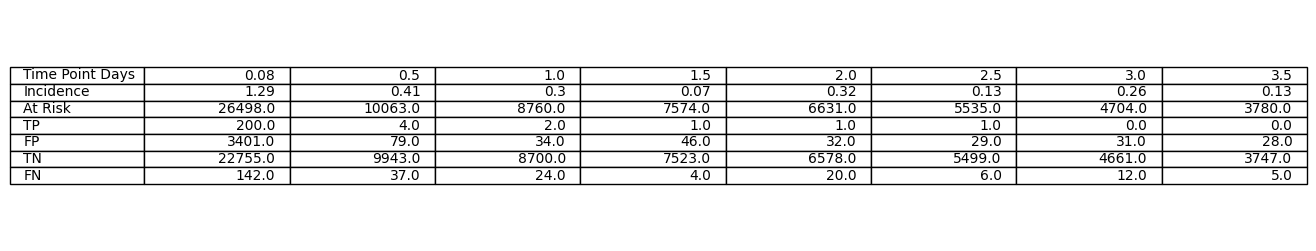

In [22]:
fig, ax = plt.subplots(figsize=(15, 3)) 
ax.axis("off")

# Add the table
ax.table(cellText=table_df.values,
         rowLabels=['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN'],
         loc="center")

plt.savefig(os.path.join(data_save_path, 'table.png'))
plt.show()
plt.close()

In [23]:
table_df.to_csv(os.path.join(data_save_path, 'table.csv'))